In [30]:
# 1st ML model (very basic) - for predicting the Yield of crop browth (in tonnes per hectare)
## Using what I have learnt so far and following walkthrough tutorials to piece it all together
### importing & reading a downloaded CSV file, plotting & linear regression, sperating testing and training data & error checks.
#### The purpose of this model was to put the theory of what I have been learning so far into practice with a real life dataset from kraggle.

In [31]:
import pandas as pd
df = pd.read_csv(r"C:\Users\sethl\OneDrive\Documents\AI Engineering Work\Datasets (examples)\crop_yield.csv")
df 

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


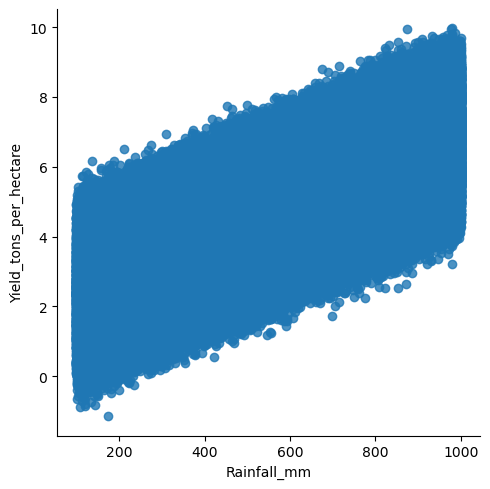

In [32]:
import seaborn as sns
sns.lmplot(x="Rainfall_mm", y = "Yield_tons_per_hectare", data = df, fit_reg =True, ci = None)

<Axes: ylabel='Frequency'>

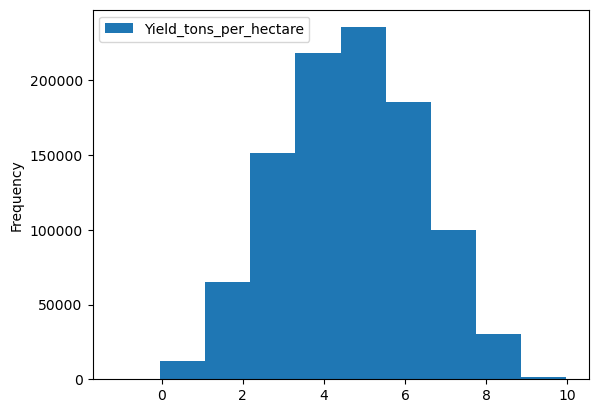

In [33]:
df.plot.hist(y = "Yield_tons_per_hectare")

In [34]:
train = df[df.index > 800000].copy()
test = df[df.index>= 800000].copy()


In [35]:
train.shape

(199999, 10)

In [36]:
test.shape

(200000, 10)

In [37]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [38]:
predictors = ["Rainfall_mm", "Fertilizer_Used"]
target = ["Yield_tons_per_hectare"]

In [39]:
reg.fit(train[predictors], train ["Yield_tons_per_hectare"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
predictions = reg.predict(test[predictors])

In [41]:
test["predictions"] = predictions

In [42]:
test

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,predictions
800000,East,Chalky,Soybean,213.157659,18.556476,False,True,Sunny,110,2.312108,2.216605
800001,West,Sandy,Maize,598.286817,22.132085,False,False,Rainy,133,3.512957,4.139760
800002,West,Chalky,Maize,357.983391,36.250599,True,True,Sunny,140,4.701846,4.439989
800003,West,Silt,Barley,926.441658,25.792187,False,True,Rainy,136,6.717572,5.778411
800004,South,Loam,Cotton,111.669782,26.690313,True,True,Cloudy,120,4.257699,3.210015
...,...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586,2.664264
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594,7.311309
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182,6.983587
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159,3.613072


In [43]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(test["Yield_tons_per_hectare"], test["predictions"])
error

0.6618915439516115

In [44]:
df.describe()["Yield_tons_per_hectare"]

count    1000000.000000
mean           4.649472
std            1.696572
min           -1.147613
25%            3.417637
50%            4.651808
75%            5.879200
max            9.963372
Name: Yield_tons_per_hectare, dtype: float64

In [45]:
test[test["Fertilizer_Used"] == True]

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,predictions
800002,West,Chalky,Maize,357.983391,36.250599,True,True,Sunny,140,4.701846,4.439989
800004,South,Loam,Cotton,111.669782,26.690313,True,True,Cloudy,120,4.257699,3.210015
800005,North,Chalky,Soybean,760.272155,22.820087,True,True,Sunny,126,7.344860,6.448830
800006,South,Loam,Soybean,706.371454,33.710230,True,True,Cloudy,101,7.429569,6.179675
800008,North,Loam,Maize,510.510269,33.146649,True,True,Sunny,88,5.876400,5.201637
...,...,...,...,...,...,...,...,...,...,...,...
999991,East,Clay,Soybean,349.872329,17.036670,True,False,Cloudy,100,3.033848,4.399486
999993,West,Loam,Maize,196.392138,30.261504,True,True,Rainy,107,3.689114,3.633078
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594,7.311309
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182,6.983587


In [46]:
errors = (test["Yield_tons_per_hectare"] - predictions).abs()
errors

800000    0.095502
800001    0.626802
800002    0.261857
800003    0.939162
800004    1.047684
            ...   
999995    1.316678
999996    0.000285
999997    1.220405
999998    1.542913
999999    0.618655
Name: Yield_tons_per_hectare, Length: 200000, dtype: float64

In [47]:
error_by_rainfall = errors.groupby(test["Rainfall_mm"]).mean()

In [48]:
error_by_rainfall

Rainfall_mm
100.011989    0.526487
100.012778    0.600758
100.012870    0.628224
100.013224    0.928836
100.021326    0.975311
                ...   
999.984840    0.831624
999.986312    1.060657
999.986494    1.259425
999.987914    0.677629
999.991820    0.518892
Name: Yield_tons_per_hectare, Length: 200000, dtype: float64

In [49]:
Yield = test["Yield_tons_per_hectare"].groupby(test["Rainfall_mm"]).mean()

In [50]:
error_ratio = error_by_rainfall / Yield

In [51]:
error_ratio

Rainfall_mm
100.011989    0.143134
100.012778    0.235495
100.012870    0.275557
100.013224    0.417835
100.021326    0.448102
                ...   
999.984840    0.122042
999.986312    0.147184
999.986494    0.170076
999.987914    0.097246
999.991820    0.092218
Name: Yield_tons_per_hectare, Length: 200000, dtype: float64

<Axes: ylabel='Frequency'>

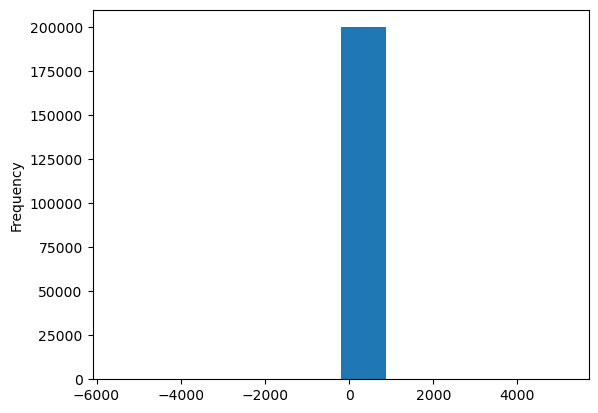

In [52]:
error_ratio.plot.hist()